In [1]:
# %%
import numpy as np
import jax.numpy as jnp
from jax import lax
import numba
import matplotlib.pyplot as plt
import math

# # %%
# @numba.jit(inline='always', nopython=True, cache=True)
# def cpu_cubic1d(t, f_minus1, f_0, f_1, f_2):
#     a = 2 * f_0
#     b = -1 * f_minus1 + f_1
#     c = 2 * f_minus1 - 5 * f_0 + 4 * f_1 - f_2
#     d = -1 * f_minus1 + 3 * f_0 - 3 * f_1 + f_2
#     return 0.5 * (a + t * b + t ** 2 * c + t ** 3 * d)

# # %%
# @numba.jit(inline='always', nopython=True, cache=True)
# def cpu_bicubic(dx, dy, region):
#     # Perform 4 1D interpolations by dx along the rows of region
#     b_minus1 = cpu_cubic1d(dx, region[0, 0], region[0, 1], region[0, 2], region[0, 3])
#     b_0 = cpu_cubic1d(dx, region[1, 0], region[1, 1], region[1, 2], region[1, 3])
#     b_1 = cpu_cubic1d(dx, region[2, 0], region[2, 1], region[2, 2], region[2, 3])
#     b_2 = cpu_cubic1d(dx, region[3, 0], region[3, 1], region[3, 2], region[3, 3])
#     # perform 1 interpolation by dy along the column of b values
#     interpolated_value = cpu_cubic1d(dy, b_minus1, b_0, b_1, b_2)
#     return interpolated_value

# # %%
# @numba.jit(inline='always', nopython=True, cache=True)
# def get_or_fill(arr, y, x, fill_value):
#     """Returns (arr[y, x], False) unless that would be out of bounds,
#     or not-a-number, in which case returns (`fill_value`, True)"""
#     ny, nx = arr.shape
#     if y < ny and y >= 0 and x < nx and x >= 0:
#         val = arr[y,x]
#         if not np.isnan(val):
#             return val, False
#     return fill_value, True

# @numba.jit(nopython=True, cache=True)
# def matrix_transform_image(source_image, transform_mtx, dest_image, interpolation_fill_value, missing_fill_value):
#     '''
#     Parameters
#     ----------
#     source_image : np.ndarray
#     transform_mtx : np.ndarray
#     dest_image : np.ndarray
#     interpolation_fill_value : float
#         When a source image location overlaps a border or NaN value,
#         the final interpolated value is calculated using this value
#         in place of the undefined pixels
#     missing_fill_value : float
#         When a transformed image location maps to an out-of-bounds
#         location in the source image, or to a location where the
#         interpolation domain is >1/2 NaN values, this value
#         is used for the destination pixel
#     '''
#     cutout = np.zeros((4, 4))
#     for dest_y in range(dest_image.shape[0]):
#         for dest_x in range(dest_image.shape[1]):
#             x = transform_mtx[0, 0] * dest_x + transform_mtx[0, 1] * dest_y + transform_mtx[0, 2]
#             y = transform_mtx[1, 0] * dest_x + transform_mtx[1, 1] * dest_y + transform_mtx[1, 2]
#             x_int = int(math.floor(x))
#             x_frac = x - x_int
#             y_int = int(math.floor(y))
#             y_frac = y - y_int

#             n_good_pix = 0
#             for i in range(4):
#                 for j in range(4):
#                     src_y, src_x = y_int + (i - 1), x_int + (j - 1)
#                     val, was_fill = get_or_fill(source_image, src_y, src_x, interpolation_fill_value)
#                     if not was_fill:
#                         n_good_pix += 1
#                     cutout[i, j] = val
#             if n_good_pix > 8:  # 1/2 of the interpolation kernel entries
#                 dest_image[dest_y, dest_x] = cpu_bicubic(x_frac, y_frac, cutout)
#             else:
#                 dest_image[dest_y, dest_x] = missing_fill_value
#     return dest_image

# %%
xform = np.array([
    [1, 0, -2.5],
    [0, 1, -2.5],
    [0, 0, 1],
]).astype(float)

image = np.arange(64).reshape(8,8).astype(float)
dest_img = np.zeros_like(image)

# # %%
# plt.subplot(121)
# plt.imshow(image)
# plt.subplot(122)
# plt.imshow(matrix_transform_image(image, xform, dest_img, 0, 0))

# %%
# %timeit matrix_transform_image(image, xform, dest_img, 0, 0)

# %%
import jax
import jax.numpy as jnp

def _cut_out(source_image, x_int, y_int, fill_value):
    source_h, source_w = source_image.shape
    cutout = jnp.zeros((4, 4), dtype=source_image.dtype)
    # loop over rows
    def _outer_loop(j, result):
        # loop over cols
        def _inner_loop(i, result_row):
            src_y, src_x = y_int + (j - 1), x_int + (i - 1)
            # this is just doing: (src_y < source_h and src_y >= 0 and src_x < source_w and src_x >= 0)
            new_value = jax.lax.select(
                src_y < source_h,
                jax.lax.select(
                    src_y >= 0,
                    jax.lax.select(
                        src_x < source_w,
                        jax.lax.select(
                            src_x >= 0,
                            source_image[src_y, src_x],
                            fill_value
                        ),
                        fill_value
                    ),
                    fill_value
                ),
                fill_value
            )
            return result_row.at[i].set(new_value)
        new_row = jax.lax.fori_loop(0, 4, _inner_loop, jnp.zeros(4))
        return result.at[j].set(new_row)
    return jax.lax.fori_loop(0, 4, _outer_loop, cutout)


# %%

xc, yc = 1, 1



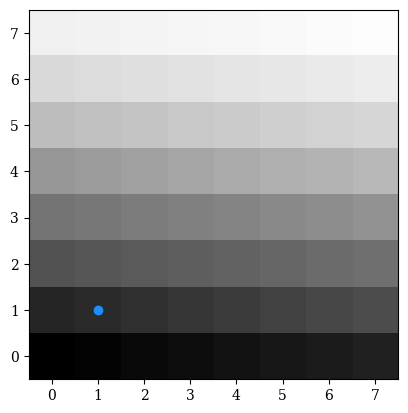

In [2]:

# %%
image = jnp.arange(64).reshape(8,8).astype(float)
plt.imshow(image, vmin=0, vmax=64, origin='lower')
plt.scatter(xc, yc)


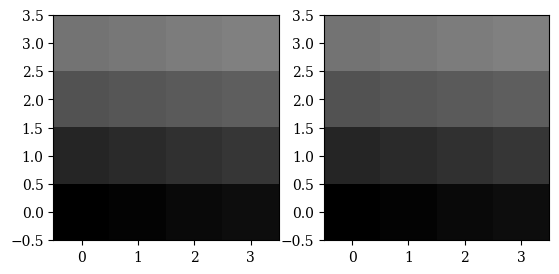

In [3]:

# %%

cutout = _cut_out(image, xc, yc, jnp.nan)
sliced_out = image[yc-1:yc+3, xc-1: xc+3]
plt.subplot(121)
plt.imshow(sliced_out, origin='lower', vmin=0, vmax=64)
plt.subplot(122)
plt.imshow(cutout, origin='lower', vmin=0, vmax=64)
assert jnp.allclose(sliced_out, cutout)


In [4]:

# %%
tiny_image = jnp.arange(4).reshape(2,2).astype(float)
_cut_out(tiny_image, 1, 1, jnp.nan)


Array([[ 0.,  1., nan, nan],
       [ 2.,  3., nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan]], dtype=float32)

In [5]:

# %%
def cubic1d(t, f_minus1, f_0, f_1, f_2):
    a = 2 * f_0
    b = -1 * f_minus1 + f_1
    c = 2 * f_minus1 - 5 * f_0 + 4 * f_1 - f_2
    d = -1 * f_minus1 + 3 * f_0 - 3 * f_1 + f_2
    return 0.5 * (a + t * b + t ** 2 * c + t ** 3 * d)

def _do_interpolation(cutout, x_frac, y_frac):
    # Perform 4 1D interpolations by dx along the rows of region
    b_minus1 = cubic1d(x_frac, cutout[0, 0], cutout[0, 1], cutout[0, 2], cutout[0, 3])
    b_0 = cubic1d(x_frac, cutout[1, 0], cutout[1, 1], cutout[1, 2], cutout[1, 3])
    b_1 = cubic1d(x_frac, cutout[2, 0], cutout[2, 1], cutout[2, 2], cutout[2, 3])
    b_2 = cubic1d(x_frac, cutout[3, 0], cutout[3, 1], cutout[3, 2], cutout[3, 3])
    # perform 1 interpolation by dy along the column of b values
    interpolated_value = cubic1d(y_frac, b_minus1, b_0, b_1, b_2)
    return interpolated_value


# %%
def matrix_transform_image(source_image, transform_mtx, dest_shape, fill_value, float_dtype=jnp.float32):
    n, m = dest_shape
    source_image = source_image.astype(float_dtype)
    fill_value = float_dtype(fill_value)
    transform_mtx = transform_mtx.astype(float_dtype)

    # loop over rows
    def outer_loop(dest_y, acc):
        # loop over columns
        def inner_loop(dest_x, inner_acc):
            x = transform_mtx[0, 0] * dest_x + transform_mtx[0, 1] * dest_y + transform_mtx[0, 2]
            y = transform_mtx[1, 0] * dest_x + transform_mtx[1, 1] * dest_y + transform_mtx[1, 2]
            x_frac = x - jnp.floor(x)
            x_int = jnp.floor(x).astype(int)
            y_frac = y - jnp.floor(y)
            y_int = jnp.floor(y).astype(int)
            new_value = _do_interpolation(_cut_out(source_image, x_int, y_int, fill_value), x_frac, y_frac)
            return inner_acc.at[dest_y, dest_x].set(new_value)

        return jax.lax.fori_loop(0, m, inner_loop, acc)

    result = jnp.zeros(dest_shape)
    result = jax.lax.fori_loop(0, n, outer_loop, result)
    return result


Finished tracing + transforming matrix_transform_image for pjit in 0.023067713 sec
Compiling matrix_transform_image with global shapes and types [ShapedArray(float32[8,8]), ShapedArray(float32[3,3])]. Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(matrix_transform_image) in 0.036249161 sec
Finished XLA compilation of jit(matrix_transform_image) in 0.286434889 sec


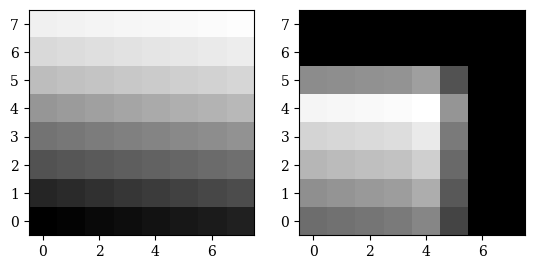

In [6]:

# Test with a sample array
transform = jnp.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
]).astype(float)
input_array = jnp.array([[1, 2], [3, 4]], dtype=jnp.float32)
result = jax.jit(matrix_transform_image, static_argnames=['dest_shape'])(input_array, transform, input_array.shape, 0)

assert jnp.allclose(input_array, result)


# %%
xform = jnp.array([
    [1, 0, -2.5],
    [0, 1, -2.5],
    [0, 0, 1],
]).astype(float)

jitted_matrix_transform_image = jax.jit(matrix_transform_image, static_argnames=['dest_shape', 'fill_value'])
with jax.log_compiles():
    dest_img = jitted_matrix_transform_image(image, xform, image.shape, 0)

# %%


# %%
xform2 = jnp.array([
    [1, 0, 2.5],
    [0, 1, 2.5],
    [0, 0, 1],
]).astype(float)


with jax.log_compiles():
    dest_img = jitted_matrix_transform_image(image, xform2, image.shape, 0)

# %%

plt.subplot(121)
plt.imshow(image, origin='lower', vmin=0, vmax=64)
plt.subplot(122)
plt.imshow(dest_img, origin='lower', vmin=0, vmax=64)


In [7]:

# %%
%timeit jax.block_until_ready(jitted_matrix_transform_image(image, xform, image.shape, 0))


7.52 ms ± 1.41 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:

# %%
%timeit jax.block_until_ready(jitted_matrix_transform_image(image, xform, image.shape, 0))


6.93 ms ± 1.03 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


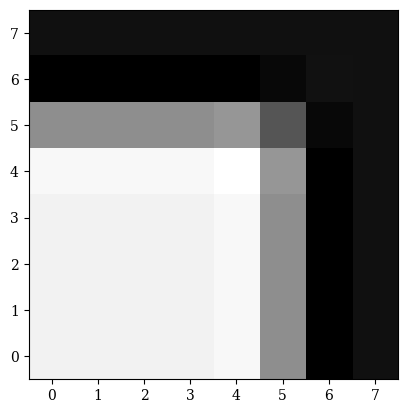

In [9]:

# %%
plt.imshow(jax.grad(lambda *x: jitted_matrix_transform_image(*x).sum())(image, xform, image.shape, 0))


In [10]:

# %%
n_iter = 1000
image_cube = jnp.repeat(image[jnp.newaxis, :, :], n_iter, axis=0)
xform_cube = jnp.repeat(xform[jnp.newaxis, :, :], n_iter, axis=0)

# %%
image_cube.shape


(1000, 8, 8)

In [11]:

# %%
jax.vmap(jitted_matrix_transform_image, in_axes=[0, 0, None, None])(image_cube, xform_cube, image.shape, 0)


Array([[[ 0.00000e+00,  0.00000e+00,  0.00000e+00, ...,  0.00000e+00,
          0.00000e+00,  0.00000e+00],
        [ 0.00000e+00,  0.00000e+00,  3.90625e-03, ..., -1.56250e-01,
         -2.18750e-01, -2.81250e-01],
        [ 0.00000e+00,  3.12500e-02, -2.81250e-01, ...,  7.50000e-01,
          1.25000e+00,  1.75000e+00],
        ...,
        [ 0.00000e+00, -1.25000e+00,  9.93750e+00, ...,  2.25000e+01,
          2.35000e+01,  2.45000e+01],
        [ 0.00000e+00, -1.75000e+00,  1.39375e+01, ...,  3.05000e+01,
          3.15000e+01,  3.25000e+01],
        [ 0.00000e+00, -2.25000e+00,  1.79375e+01, ...,  3.85000e+01,
          3.95000e+01,  4.05000e+01]],

       [[ 0.00000e+00,  0.00000e+00,  0.00000e+00, ...,  0.00000e+00,
          0.00000e+00,  0.00000e+00],
        [ 0.00000e+00,  0.00000e+00,  3.90625e-03, ..., -1.56250e-01,
         -2.18750e-01, -2.81250e-01],
        [ 0.00000e+00,  3.12500e-02, -2.81250e-01, ...,  7.50000e-01,
          1.25000e+00,  1.75000e+00],
        ...,


In [12]:

# %%
%timeit jax.block_until_ready(jax.vmap(jitted_matrix_transform_image, in_axes=[0, 0, None, None])(image_cube, xform_cube, image.shape, 0))


7.81 ms ± 45.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [13]:

# %%
7920 / n_iter


7.92

In [44]:

# %%
from interpax import Interpolator2D

# %%
xs = jnp.arange(5, dtype=float)
ys = jnp.arange(5, dtype=float)
xx, yy = jnp.meshgrid(xs, ys)

# %%
coords = jnp.stack([xx.flatten(), yy.flatten(), jnp.ones_like(xx.flatten())])

# %%
xform = jnp.array([
    [1, 0, 2.4],
    [0, 1, 1.6],
    [0, 0, 1],
])

# # %%
# def interpax_matrix_transform_image(source_image, transform_mtx, dest_shape, fill_value, float_dtype=jnp.float32):
#     ys = jnp.arange(source_image.shape[0], dtype=float)
#     xs = jnp.arange(source_image.shape[1], dtype=float)    
#     interp = Interpolator2D(xs, ys, source_image, extrap=[[-0.5, 7.5], [-0.5, 7.5]])
#     # interp = Interpolator2D(xx.flatten(), yy.flatten(), source_image, extrap=fill_value)
#     dest_ys = jnp.arange(dest_shape[0], dtype=float)
#     dest_xs = jnp.arange(dest_shape[1], dtype=float)
#     dest_xx, dest_yy = jnp.meshgrid(dest_xs, dest_ys)
#     coords = jnp.stack([dest_xx.flatten(), dest_yy.flatten(), jnp.ones_like(dest_xx.flatten())])
#     src_coords = transform_mtx @ coords
#     print(src_coords)
#     return interp(src_coords[0], src_coords[1]).reshape(dest_shape)

# # %%
# plt.imshow(interpax_matrix_transform_image(image, xform, image.shape, 0))


In [45]:

# %%
jitted_interpax_matrix_transform_image = jax.jit(interpax_matrix_transform_image, static_argnames=['dest_shape', 'fill_value'])

with jax.log_compiles():
    dest_img = jitted_interpax_matrix_transform_image(image, xform2, image.shape, 0)


Finished tracing + transforming fun for pjit in 0.003848553 sec
Finished tracing + transforming fun for pjit in 0.003349066 sec
Finished tracing + transforming fun for pjit in 0.002444029 sec
Finished tracing + transforming interpax_matrix_transform_image for pjit in 0.018938780 sec
Compiling interpax_matrix_transform_image with global shapes and types [ShapedArray(float32[8,8]), ShapedArray(float32[3,3])]. Argument mapping: (UnspecifiedValue, UnspecifiedValue).


Finished jaxpr to MLIR module conversion jit(interpax_matrix_transform_image) in 0.061196327 sec
Finished XLA compilation of jit(interpax_matrix_transform_image) in 0.749390125 sec


In [46]:

# %%
%timeit jax.block_until_ready(jax.vmap(jitted_interpax_matrix_transform_image, in_axes=[0, 0, None, None])(image_cube, xform_cube, image.shape, 0))

633 μs ± 212 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


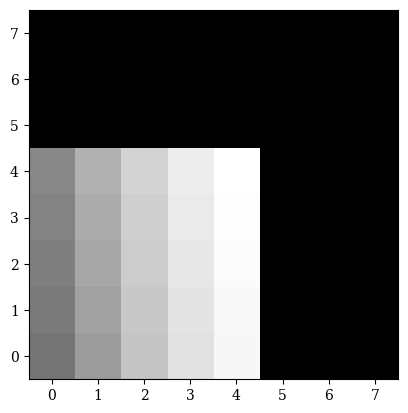

In [51]:

# %%
def interpax_matrix_transform_image(source_image, transform_mtx, dest_shape, fill_value, float_dtype=jnp.float32):
    ys = jnp.arange(source_image.shape[0], dtype=float)
    xs = jnp.arange(source_image.shape[1], dtype=float)    
    interp = Interpolator2D(xs, ys, source_image, extrap=fill_value) #, extrap=((-0.5, source_image.shape[0] + 0.5),(-0.5, source_image.shape[1] + 0.5)))
    # interp = Interpolator2D(xx.flatten(), yy.flatten(), source_image, extrap=fill_value)
    dest_ys = jnp.arange(dest_shape[0], dtype=float)
    dest_xs = jnp.arange(dest_shape[1], dtype=float)
    dest_xx, dest_yy = jnp.meshgrid(dest_xs, dest_ys)
    coords = jnp.stack([dest_xx.flatten(), dest_yy.flatten(), jnp.ones_like(dest_xx.flatten())])
    src_coords = transform_mtx @ coords
    # print(src_coords)
    return interp(src_coords[0], src_coords[1]).reshape(dest_shape)

# %%
plt.imshow(interpax_matrix_transform_image(image, xform2, image.shape, 0))


In [52]:
def rotate_image(theta_rad: float) -> np.ndarray:
    '''Transform matrix taking [x, y, 1] -> [x', y', 1] where (x', y') are
    rotated CW by theta so an image gets rotated CCW'''
    return np.array([
        [np.cos(-theta_rad), -np.sin(-theta_rad), 0],
        [np.sin(-theta_rad), np.cos(-theta_rad), 0],
        [0, 0, 1]
    ])

def translate_image(dx: float, dy: float) -> np.ndarray:
    '''Transform matrix taking [x, y, 1] -> [x - dx, y - dy, 1]
    so that an image feature at (x, y) is translated to (x + dx, y + dy)'''
    return np.array([
        [1, 0, -dx],
        [0, 1, -dy],
        [0, 0, 1]
    ])

def scale_image(sx: float, sy: float) -> np.ndarray:
    '''Transform matrix taking [x, y, 1] -> [x / sx, y / sy, 1]
    so that an image feature at (x, y) is scaled to (sx * x, sy * y)'''
    return np.array([
        [1/sx, 0, 0],
        [0, 1/sy, 0],
        [0, 0, 1]
    ])

def center_x_y(im_shape: tuple[int, int]) -> tuple[float, float]:
    '''Pixel coordinates for the center of `im` in (x, y) order'''
    return (im_shape[1] - 1) / 2, (im_shape[0] - 1) / 2

def rotate_about_center(src_shape, dest_shape, theta_rad):
    '''Transform matrix taking [x, y, 1] -> [x', y', 1] where (x', y') are
    rotated CW by theta so an image gets rotated CCW about
    its center (rather than the origin)'''
    cx_src, cy_src = center_x_y(src_shape)
    cx_dest, cy_dest = center_x_y(dest_shape)
    return translate_image(-cx_src, -cy_src) @ rotate_image(theta_rad) @ translate_image(cx_dest, cy_dest)

In [54]:
xx, yy = np.meshgrid(np.arange(16,), np.arange(16))

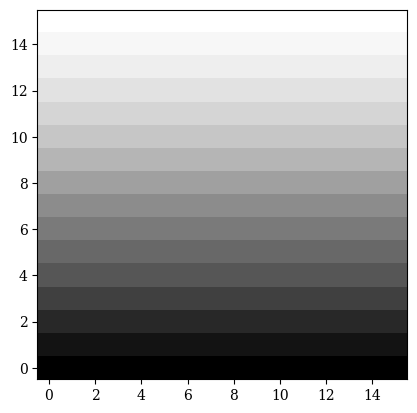

In [57]:
plt.imshow(xx)
plt.imshow(interpax_matrix_transform_image(xx, np.eye(3), xx.shape, 0))

In [53]:
from ipywidgets import interact

@interact(theta=(0, 2 * np.pi, 0.1))
def translation(theta=0):
    
    img = dd.f_test(128)
    xform = rotate_about_center(img.shape, img.shape, theta)
    print(xform)
    plt.imshow(interpax_matrix_transform_image(img, xform, img.shape, 0))

interactive(children=(FloatSlider(value=0.0, description='theta', max=6.283185307179586), Output()), _dom_clas…

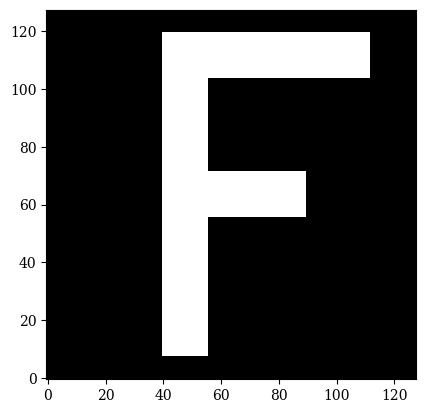

In [50]:
plt.imshow(dd.f_test(128))

In [20]:

# %%
jitted_interpax_matrix_transform_image = jax.jit(interpax_matrix_transform_image, static_argnames=['dest_shape', 'fill_value'])

with jax.log_compiles():
    dest_img = jitted_interpax_matrix_transform_image(image, xform2, image.shape, 0)


Finished tracing + transforming fun for pjit in 0.002000570 sec
Finished tracing + transforming fun for pjit in 0.001790285 sec
Finished tracing + transforming fun for pjit in 0.001836061 sec
Finished tracing + transforming interpax_matrix_transform_image for pjit in 0.011456966 sec
Compiling interpax_matrix_transform_image with global shapes and types [ShapedArray(float32[8,8]), ShapedArray(float32[3,3])]. Argument mapping: (UnspecifiedValue, UnspecifiedValue).
Finished jaxpr to MLIR module conversion jit(interpax_matrix_transform_image) in 0.041960716 sec
Finished XLA compilation of jit(interpax_matrix_transform_image) in 0.548018456 sec


In [21]:

# %%
%timeit jax.block_until_ready(jax.vmap(jitted_interpax_matrix_transform_image, in_axes=[0, 0, None, None])(image_cube, xform_cube, image.shape, 0))


498 μs ± 124 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)
